# WM-811K Data Exploration

This notebook inspects the processed development subset used for rapid iteration.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

metadata_path = REPO_ROOT / "data/processed/wm811k/metadata_dev.csv"
metadata = pd.read_csv(metadata_path)
metadata.head()

,array_path,label,defect_type,is_anomaly,split,source_split,original_height,original_width
0,data/processed/wm811k/arrays/wafer_0000000.npy,none,none,0,train,Training,25,27
1,data/processed/wm811k/arrays/wafer_0000001.npy,none,none,0,train,Test,29,26
2,data/processed/wm811k/arrays/wafer_0000002.npy,none,none,0,train,Training,33,37
3,data/processed/wm811k/arrays/wafer_0000003.npy,none,none,0,train,Training,25,27
4,data/processed/wm811k/arrays/wafer_0000004.npy,none,none,0,train,Test,29,26


In [3]:
print(f"Rows: {len(metadata)}")
print("\nSplit counts:")
display(metadata["split"].value_counts().rename_axis("split").to_frame("count"))

print("\nAnomaly counts:")
display(metadata["is_anomaly"].value_counts().rename_axis("is_anomaly").to_frame("count"))

print("\nDefect types:")
display(metadata["defect_type"].value_counts().head(10).rename_axis("defect_type").to_frame("count"))

Rows: 2400

Split counts:


,count
split,
train,1600
test,600
val,200



Anomaly counts:


,count
is_anomaly,
0,2000
1,400



Defect types:


,count
defect_type,
none,2000
Edge-Ring,136
Edge-Loc,91
Center,74
Loc,52
Scratch,20
Donut,13
Random,10
Near-full,4


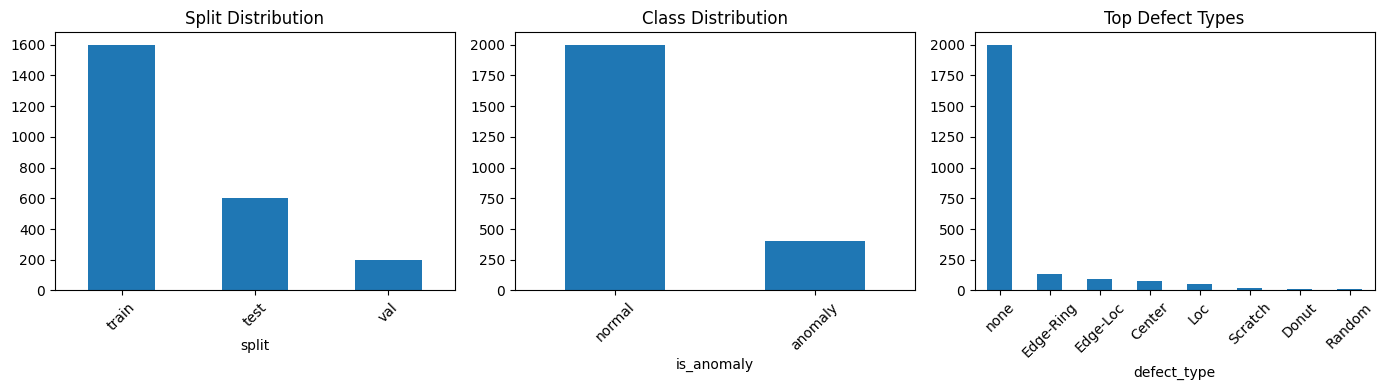

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metadata["split"].value_counts().plot(kind="bar", ax=axes[0], title="Split Distribution")
metadata["is_anomaly"].map({0: "normal", 1: "anomaly"}).value_counts().plot(kind="bar", ax=axes[1], title="Class Distribution")
metadata["defect_type"].value_counts().head(8).plot(kind="bar", ax=axes[2], title="Top Defect Types")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

In [5]:
def load_wafer(relative_path: str) -> np.ndarray:
    return np.load(REPO_ROOT / relative_path)

normal_examples = metadata[metadata["is_anomaly"] == 0].sample(6, random_state=42)
anomaly_examples = metadata[metadata["is_anomaly"] == 1].sample(6, random_state=42)

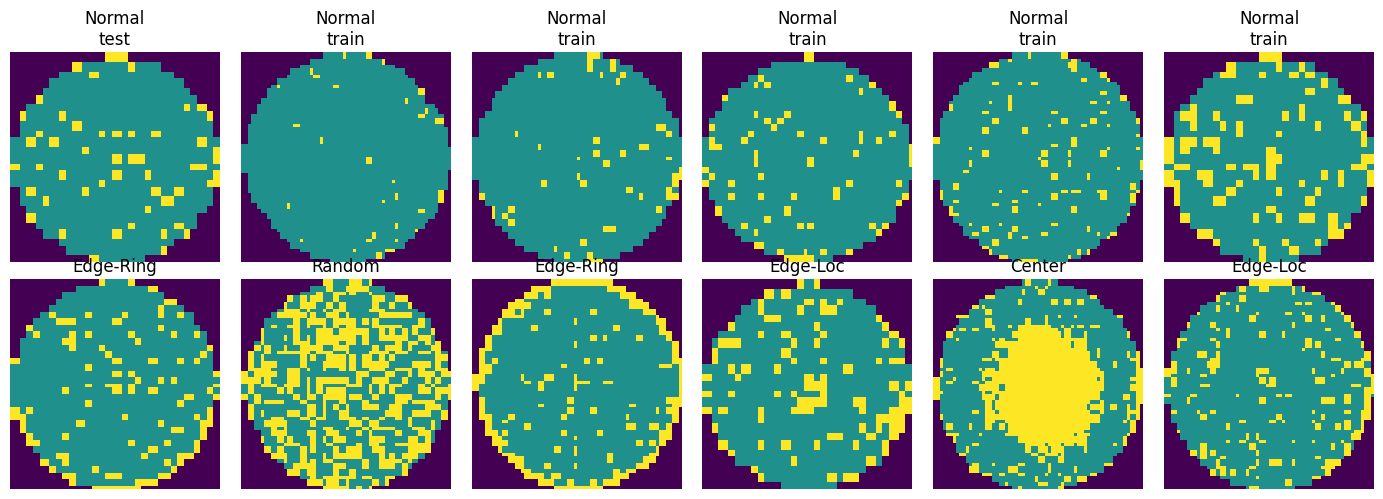

In [6]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))

for idx, (_, row) in enumerate(normal_examples.iterrows()):
    axes[0, idx].imshow(load_wafer(row["array_path"]), cmap="viridis")
    axes[0, idx].set_title(f"Normal\n{row['split']}")
    axes[0, idx].axis("off")

for idx, (_, row) in enumerate(anomaly_examples.iterrows()):
    axes[1, idx].imshow(load_wafer(row["array_path"]), cmap="viridis")
    axes[1, idx].set_title(f"{row['defect_type']}")
    axes[1, idx].axis("off")

plt.tight_layout()

In [7]:
metadata[["original_height", "original_width"]].describe()

,original_height,original_width
count,2400.000000,2400.000000
mean,35.627500,34.967083
std,12.210072,11.971071
min,22.000000,25.000000
25%,27.000000,27.000000
50%,33.000000,33.000000
75%,41.000000,40.000000
max,212.000000,175.000000
